In [1]:
from pathlib import Path
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import torch
sns.set_style(style="whitegrid")


%load_ext autoreload
%autoreload 2

NB   = Path.cwd()
ROOT = NB.parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from data_pipeline.config import CLEANED

RUN_DIR = Path(ROOT / "models/gae_run1")
CKPT = RUN_DIR / "best.pt"
CONF = RUN_DIR / "config.json"
RESULTS = RUN_DIR / "results.json"  # created by train_gae when save_outdir set
RUN_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# --- 1) Load panel exported from 02_simulator ---
panel = pd.read_csv(CLEANED / "hedging_panel_spx.csv", parse_dates=["date"])
panel = panel.sort_values("date").reset_index(drop=True)

print("Panel window:", panel["date"].min(), "→", panel["date"].max())
print("Columns:", list(panel.columns)[:12], "...")

Panel window: 2005-01-21 00:00:00 → 2023-08-31 00:00:00
Columns: ['date', 'close_spy', 'vix', 'rate_10y', 'hvol_10d', 'hvol_14d', 'hvol_30d', 'hvol_60d', 'hvol_91d', 'hvol_122d', 'hvol_152d', 'hvol_182d'] ...


In [3]:
from rl_agent.train_ac_gae import PolicyValueNet
from rl_agent.experiment import build_envs, deterministic_rewards
from rl_agent.trainer import evaluate_env

cfg = json.loads(CONF.read_text())
envs = build_envs(
    panel=panel,  # reuse your processed panel from earlier notebooks
    features=cfg["features"],
    train_end=cfg["train_end"],
    valid_end=cfg["valid_end"],
    window=cfg["window"],
    txn_cost_bps=cfg["txn_cost_bps"],
    pos_limit=cfg["pos_limit"],
    reward_scale=1e4,
)
env_tr, env_va, env_te = envs["env_tr"], envs["env_va"], envs["env_te"]

obs = env_tr.reset()
print("obs.shape:", getattr(obs, "shape", None), "len(flat):", np.asarray(obs).reshape(-1).shape)


obs.shape: (30, 8) len(flat): (240,)


In [4]:
from rl_agent.train_ac_gae import PolicyValueNet, make_obs_fixer

n_features = len(cfg["features"])
to_fixed = make_obs_fixer(cfg["window"], n_features)

net = PolicyValueNet(input_dim=env_tr.reset().size, hidden=cfg["hidden"])
net.load_state_dict(torch.load(CKPT, map_location="cpu"))
net.obs_fix = to_fixed
net.pos_limit = float(cfg["pos_limit"])

metrics = {
    "train": evaluate_env(env_tr, net, deterministic=True),
    "valid": evaluate_env(env_va, net, deterministic=True),
    "test":  evaluate_env(env_te, net, deterministic=True),
}
display(pd.DataFrame(metrics).T)

train_curve = pd.read_csv(RUN_DIR / "train_bps.csv")["bps"].to_numpy()
valid_curve = pd.read_csv(RUN_DIR / "valid_bps.csv")["bps"].to_numpy()
test_curve  = pd.read_csv(RUN_DIR / "test_bps.csv")["bps"].to_numpy()


,mean,std,sharpe,steps
train,0.094777,13.625066,0.110424,7823.0
valid,0.205765,5.490651,0.594905,2474.0
test,0.233145,8.227676,0.449832,7628.0


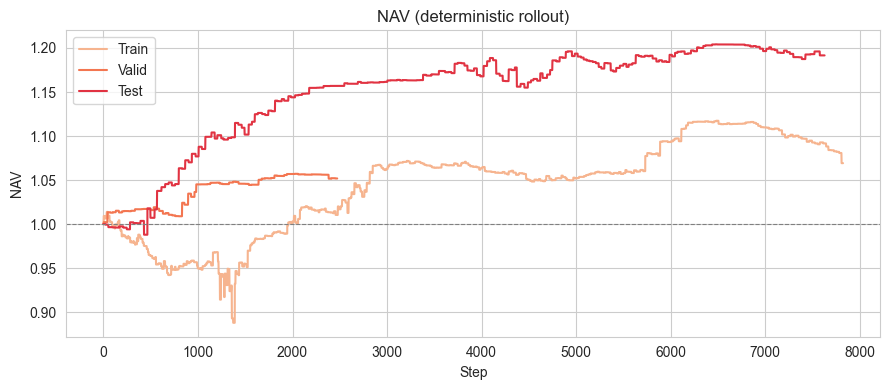

Test turnover (sum |Δpos|): 40.18


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from rl_agent.experiment import deterministic_rewards
from rl_agent.deploy import nav_curve

sns.set_palette("rocket_r")
plt.figure(figsize=(9,4))
r_tr, nav_tr = nav_curve(env_tr, net, "Train")
r_va, nav_va = nav_curve(env_va, net, "Valid")
r_te, nav_te = nav_curve(env_te, net, "Test")
plt.axhline(1.0, color="grey", lw=0.8, ls="--")
plt.title("NAV (deterministic rollout)")
plt.xlabel("Step")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()
plt.show()

rollout_te = env_te.rollout(lambda obs: net.act(obs, deterministic=True)[0])
positions = rollout_te["positions"]
turnover = np.abs(np.diff(positions)).sum()
print(f"Test turnover (sum |Δpos|): {turnover:.2f}")


In [6]:
from rl_agent.deploy import calc_drawdown, rollout_stats

summary = []
for split, (env, rewards, nav) in {
    "train": (env_tr, r_tr, nav_tr),
    "valid": (env_va, r_va, nav_va),
    "test":  (env_te, r_te, nav_te),
}.items():
    summary.append({
        "split": split,
        "mean_bps": metrics[split]["mean"] * 1e4,
        "std_bps": metrics[split]["std"] * 1e4,
        "sharpe": metrics[split]["sharpe"],
        "steps": metrics[split]["steps"],
        "max_drawdown": calc_drawdown(nav),
        "turnover": np.abs(np.diff(env.rollout(lambda obs: net.act(obs, deterministic=True)[0])["positions"])).sum()
            if split == "test" else np.nan,
    })

summary_df = pd.DataFrame(summary).set_index("split")

for split, env in {"train": env_tr, "valid": env_va, "test": env_te}.items():
    dd, turn = rollout_stats(env, net)
    summary_df.loc[split, ["max_drawdown", "turnover"]] = [dd, turn]
summary_df.to_csv(RUN_DIR / "evaluation_summary.csv")

display(summary_df)


,mean_bps,std_bps,sharpe,steps,max_drawdown,turnover
split,,,,,,
train,947.771427,136250.659816,0.110424,7823,-0.124208,69.719727
valid,2057.649864,54906.510322,0.594905,2474,-0.010024,17.008314
test,2331.454830,82276.764054,0.449832,7628,-0.028284,40.178152


In [7]:
## Save results to RUN_DIR

RUN_DIR.mkdir(parents=True, exist_ok=True)

fig_nav = plt.figure(figsize=(9,3))
  # build NAV plot
fig_nav.savefig(RUN_DIR / "nav_curves.png", dpi=150, bbox_inches="tight")

fig_hist = plt.figure(figsize=(8,3))
  # build histogram
fig_hist.savefig(RUN_DIR / "test_reward_hist.png", dpi=150, bbox_inches="tight")

summary_df.to_csv(RUN_DIR / "evaluation_summary.csv", index=True)

np.save(RUN_DIR / "train_rewards.npy", r_tr)
np.save(RUN_DIR / "valid_rewards.npy", r_va)
np.save(RUN_DIR / "test_rewards.npy",  r_te)


<Figure size 900x300 with 0 Axes>

<Figure size 800x300 with 0 Axes>

## Comparison vs Long SPY

In [8]:
from rl_agent.deploy import load_policy

policy_loaded, cfg_loaded, envs_loaded = load_policy(
    run_dir=RUN_DIR,
    panel=panel,
    device="cpu",
)

print("Loaded policy hidden dim:", cfg_loaded["hidden"])
print("Envs keys:", list(envs_loaded.keys()))


Loaded policy hidden dim: 256
Envs keys: ['env_tr', 'env_va', 'env_te', 'input_dim', 'config', 'scaler', 'TRAIN_END', 'VALID_END']


split,test,train,valid
policy,,,
gae_policy,0.449832,0.110424,0.594905
long_spy,0.210909,0.375446,0.334204


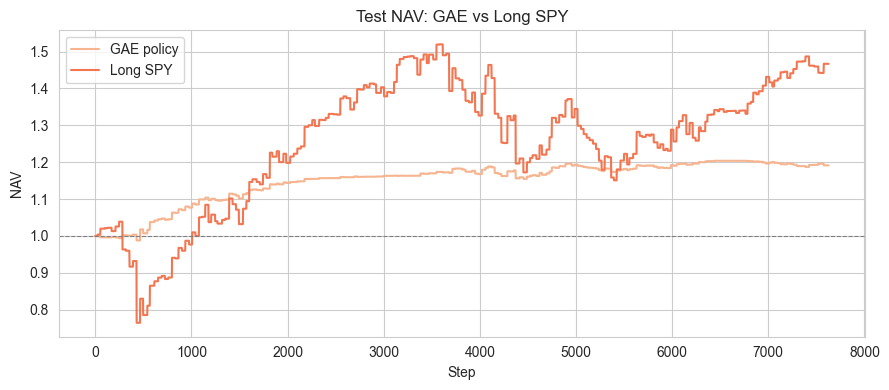

In [9]:
# --- Baseline comparison: GAE policy vs long SPY ---
from collections import OrderedDict

class _Hold:
    def __init__(self, level):
        self.level = float(level)
    def act(self, obs, deterministic=True):
        return float(self.level), None, None

comparisons = OrderedDict()
comparisons['gae_policy'] = net
comparisons['long_spy'] = _Hold(env_tr.pos_limit)

rows = []
for name, pol in comparisons.items():
    metrics2 = {
        'train': evaluate_env(env_tr, pol, deterministic=True),
        'valid': evaluate_env(env_va, pol, deterministic=True),
        'test':  evaluate_env(env_te, pol, deterministic=True),
    }
    for split, vals in metrics2.items():
        rows.append({
            'policy': name, 'split': split,
            'mean': vals['mean'], 'std': vals['std'],
            'sharpe': vals['sharpe'], 'steps': vals['steps'],
        })

results_df = pd.DataFrame(rows)
display(results_df.pivot(index='policy', columns='split', values='sharpe'))
results_df

# Overlay NAV on TEST split
sns.set_palette("rocket_r")
plt.figure(figsize=(9,4))
_ = nav_curve(env_te, net, 'GAE policy')
_ = nav_curve(env_te, _Hold(env_te.pos_limit), 'Long SPY')
plt.axhline(1.0, color='grey', lw=0.8, ls='--')
plt.title('Test NAV: GAE vs Long SPY')
plt.xlabel('Step'); plt.ylabel('NAV'); plt.legend(); plt.tight_layout(); plt.show()


In [10]:
# --- Extended metrics for GAE policy vs Long SPY ---
import numpy as np, pandas as pd
from collections import OrderedDict
from rl_agent.deploy import _max_drawdown, _nav_from_bps, _sortino_bps

policies = OrderedDict([
    ('gae_policy', net),
    ('long_spy', _Hold(env_te.pos_limit)),
])
splits = OrderedDict([('train', env_tr), ('valid', env_va), ('test', env_te)])

rows = []
for pname, pol in policies.items():
    for sname, env in splits.items():
        # deterministic rewards in bps
        r = deterministic_rewards(env, pol)
        nav = _nav_from_bps(r)
        mean_bps = float(r.mean())
        std_bps  = float(r.std(ddof=1)) if r.size > 1 else 0.0
        ann_vol_bps = float(std_bps * np.sqrt(252))
        sharpe = float((mean_bps / std_bps * np.sqrt(252)) if std_bps > 0 else 0.0)
        sortino = _sortino_bps(r)
        dd = _max_drawdown(nav)
        steps = int(r.size)
        cagr = float(nav[-1] ** (252/steps) - 1.0) if steps > 0 else 0.0
        calmar = float(cagr / abs(dd)) if dd < 0 else float('inf')
        hit_rate = float((r > 0).mean())
        var5 = float(np.quantile(r, 0.05)) if r.size else np.nan
        es5 = float(r[r <= var5].mean()) if r.size else np.nan
        rows.append({
            'policy': pname, 'split': sname, 'steps': steps,
            'mean_bps': mean_bps, 'std_bps': std_bps, 'ann_vol_bps': ann_vol_bps,
            'sharpe': sharpe, 'sortino': sortino, 'max_drawdown': dd,
            'cagr': cagr, 'calmar': calmar, 'hit_rate': hit_rate,
            'VaR5_bps': var5, 'ES5_bps': es5,
        })

metrics_df = pd.DataFrame(rows)
display(metrics_df.pivot(index='policy', columns='split', values='sharpe'))
metrics_df

# Optionally write to run dir if present
#try:
#    out = RUN_DIR / 'metrics_comparison.csv'
#    metrics_df.to_csv(out, index=False)
#    print('Saved metrics to', out)
#except Exception as e:
#    pass


split,test,train,valid
policy,,,
gae_policy,0.449832,0.110424,0.594905
long_spy,0.210909,0.375446,0.334204


,policy,split,steps,mean_bps,std_bps,ann_vol_bps,sharpe,sortino,max_drawdown,cagr,calmar,hit_rate,VaR5_bps,ES5_bps
0,gae_policy,train,7823,0.094777,13.625066,216.291217,0.110424,0.172061,-0.124208,0.002158,0.017372,0.026716,-0.038802,-14.120944
1,gae_policy,valid,2474,0.205765,5.490651,87.161383,0.594905,1.840783,-0.010024,0.005161,0.514840,0.015764,-0.027841,-2.556392
2,gae_policy,test,7628,0.233145,8.227676,130.610314,0.449832,0.823919,-0.028284,0.005807,0.205317,0.014945,-0.019983,-5.641173
3,long_spy,train,7823,1.588787,67.176587,1066.395259,0.375446,0.106994,-0.513604,0.034936,0.068022,0.033619,0.000000,-4.529963
4,long_spy,valid,2474,0.730443,34.695631,550.776071,0.334204,0.065492,-0.138285,0.017026,0.123120,0.018593,0.000000,-1.766633
5,long_spy,test,7628,0.611007,45.988662,730.047375,0.210909,0.040344,-0.263900,0.012738,0.048269,0.016256,0.000000,-2.356646


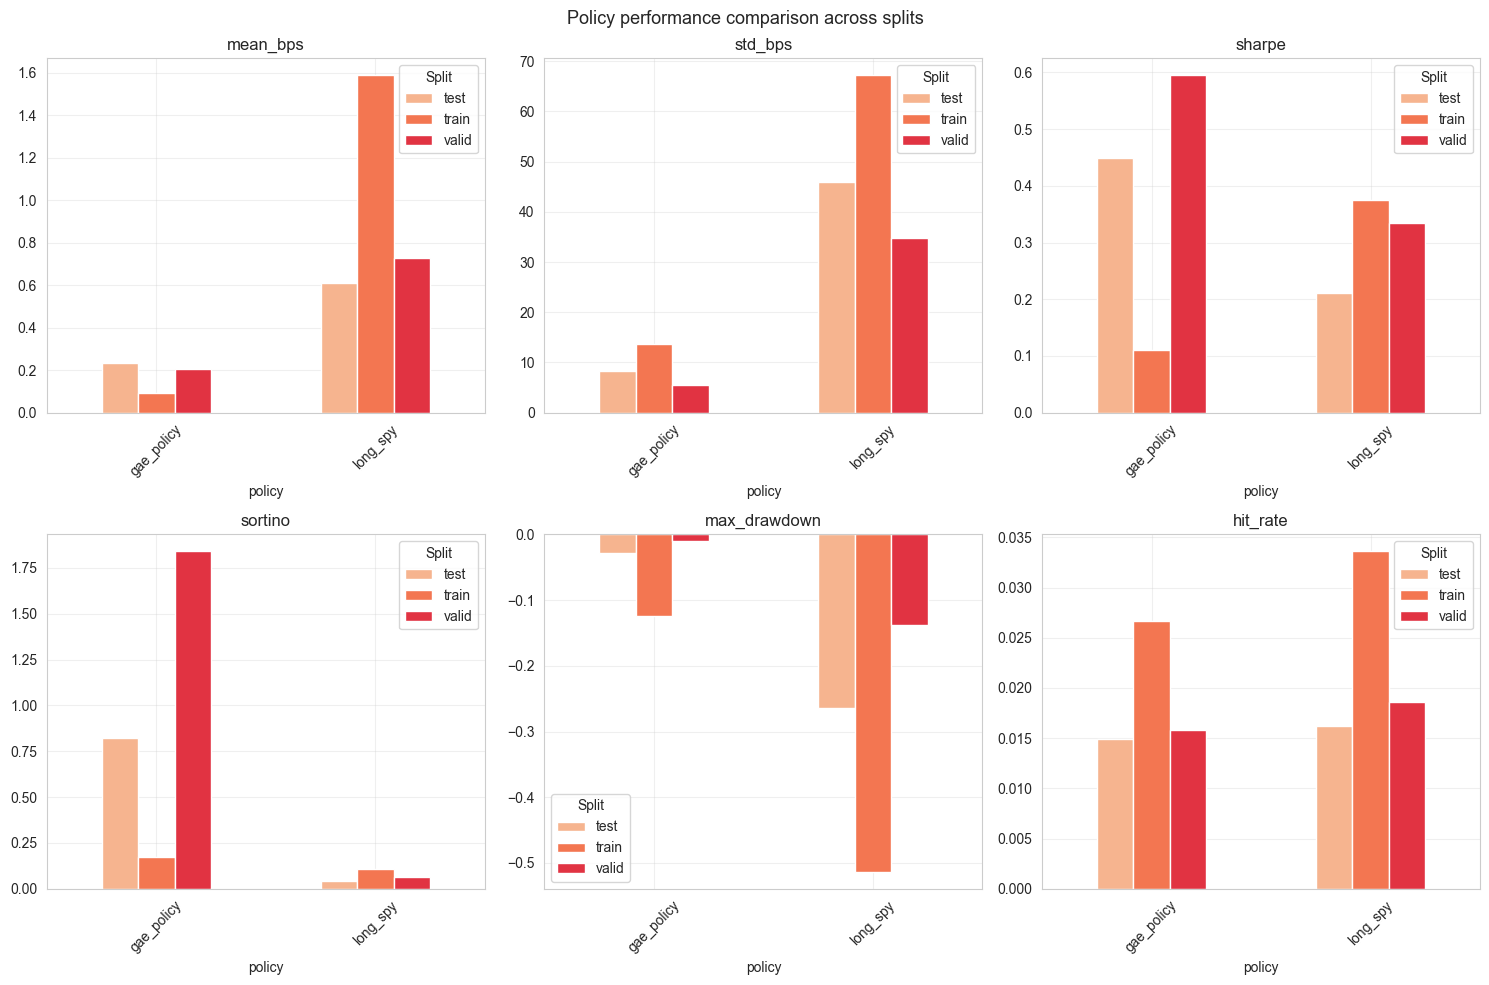

In [12]:
# Create a more readable plot for metrics comparison

sns.set_style(style="whitegrid")
sns.set_palette("rocket_r")
metrics_to_plot = ['mean_bps', 'std_bps', 'sharpe', 'sortino', 'max_drawdown', 'hit_rate']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    data = metrics_df.pivot(index='policy', columns='split', values=metric)
    data.plot(kind='bar', ax=ax, rot=45)
    ax.set_title(metric)
    ax.legend(title='Split')
    ax.grid(True, alpha=0.3)

fig.suptitle("Policy performance comparison across splits", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / "policy_performance_comparison.png", dpi=150)
plt.show()